In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
import pandas as pd

from cinnabar import plotting
from cinnabar.compare import compare_and_rank_results

from openfe_benchmarks.results._benchmark_results import get_benchmark_results

## Load Calculated Data

In [2]:
submission_ids = {
    "Sage 2.1.1 (ff14SB) TIP3P": "2026-08-25_ff14sb_openff-2.1.1_jacs",
    "Sage 2.3.0 (ff14SB) TIP3P": "2026-02-12_sage_230_jacs_set",
    r"Sage 3.0.0-$\alpha_{1b}$ TIP3P": "2026-08-05-openff3.0.0-alpha1b_tip3p-jacs",
    r"Sage 3.0.0-$\alpha_0$ OPC3": "2026-08-05_openff-3.0.0-alpha0_opc3_jacs",
    r"Sage 3.0.0-$\alpha_{1b}$ OPC3": "2026-08-04-openff3.0.0-alpha1b_opc3-jacs",
}

results = {key: get_benchmark_results(sub_id) for key, sub_id in submission_ids.items()}
for name, result in results.items():
    result.ddg_femaps(
        source=name
    )  # first run will create and cache the result for future calls

2026-08-31 12:44:31 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for ddg results - first access may be slow
2026-08-31 12:44:31 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'bace' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-31 12:44:31 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'cdk2' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-31 12:44:31 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'jnk1' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-31 12:44:31 - openfe_benchmarks.data._be

Now `results` contains `BenchmarkResults` for each system and those results can be plotted with `cinnebar` by accessing the `femap` available through `results[key].ddg_femaps()` or `results[key].dg_femaps()`. See [cinnebar documentation](https://cinnabar.openfree.energy/en/latest/tutorials/cinnabar-api.html#applying-an-experimental-shift) for more information on how to plot.

## Create Pair Plots

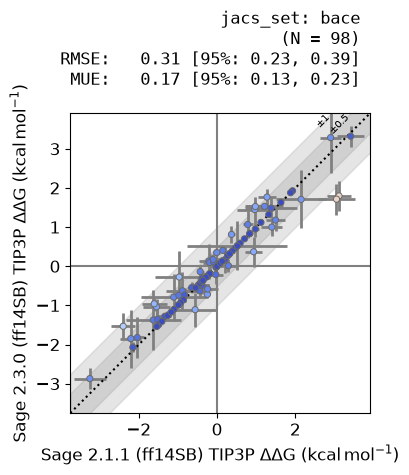

In [3]:
key1, key2 = "Sage 2.1.1 (ff14SB) TIP3P", "Sage 2.3.0 (ff14SB) TIP3P"
system_group_name = ("jacs_set", "bace")

df_sage_2_1_1 = results[key1].ddg_femaps()[system_group_name].get_relative_dataframe()
df_sage_2_3_0 = results[key2].ddg_femaps()[system_group_name].get_relative_dataframe()
# openfe_df = relative_df[relative_df["source"] == "OpenFE"].set_index(["labelA", "labelB"])
# noisy_df = relative_df[relative_df["source"] == "Noisy OpenFE"].set_index(["labelA", "labelB"])

# use numpy arrays with pair_plot
plotting.pair_plot(
    x=df_sage_2_1_1["DDG (kcal/mol)"].to_numpy(),  # provide the x values for the plot
    y=df_sage_2_3_0["DDG (kcal/mol)"].to_numpy(),  # provide the y values for the plot
    xerr=df_sage_2_1_1[
        "uncertainty (kcal/mol)"
    ].to_numpy(),  # provide the x error values for the plot
    yerr=df_sage_2_3_0[
        "uncertainty (kcal/mol)"
    ].to_numpy(),  # provide the y error values for the plot
    title=f"{system_group_name[0]}: {system_group_name[1]}",
    xlabel=key1,  # match the x and y labels to the values being plotted
    ylabel=key2,
    figsize=5,
    statistics=[
        "RMSE",
        "MUE",
    ],  # add RMSE and MUE to the plot along with the confidence intervals from bootstrapping
);

## Empirical Cumulative Distribution Function (ECDF) Plots

See [cinnebar documentation](https://cinnabar.openfree.energy/en/latest/tutorials/ecdf-plots.html) for more details

In [4]:
# Combining FEMaps
system_group_name = ("jacs_set", "bace")

femap_list = [result.ddg_femaps()[system_group_name] for result in results.values()]
combined_femap = sum(femap_list[1:], femap_list[0])

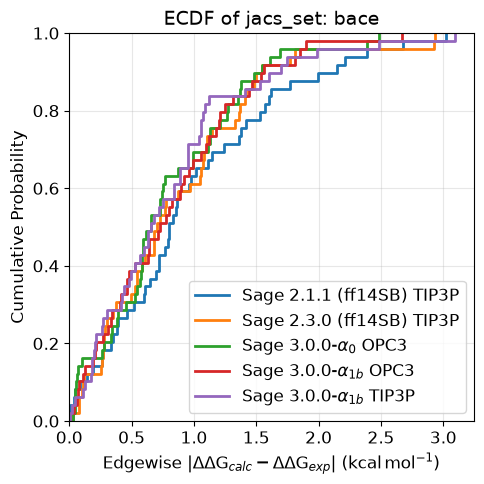

In [5]:
fig = plotting.ecdf_plot_DDGs(
    combined_femap,
    title=f"ECDF of {system_group_name[0]}: {system_group_name[1]}",
    #    sources=["Method A", "Method B"], # narrow down sources
    #    labels=["Pipeline A", "Pipeline B"], # set custom labels
    figsize=5,
    nbootstraps=0,  # optionally turn off uncertainty intervals
)

### Get All Plots

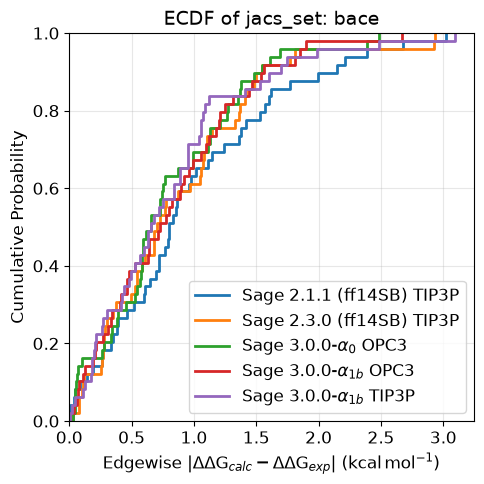

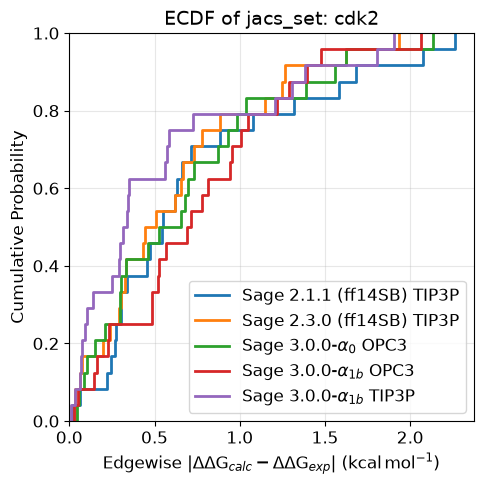

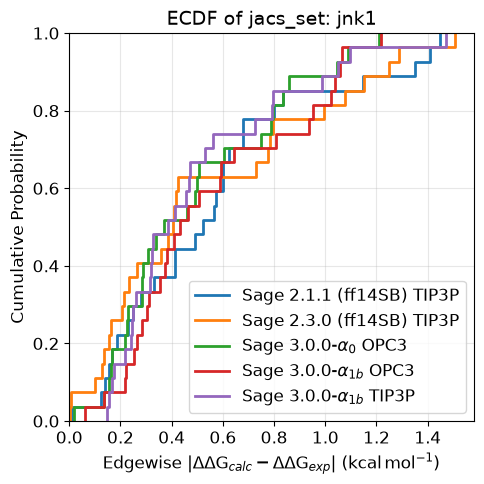

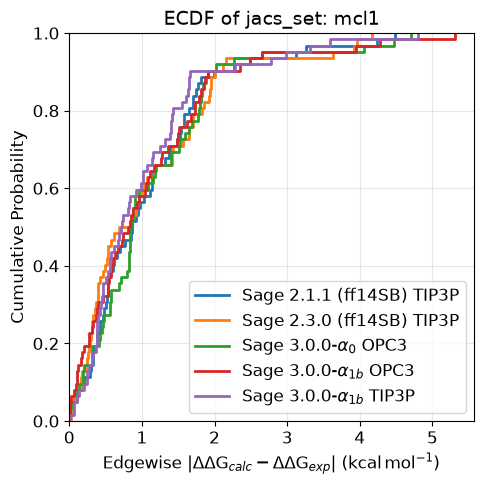

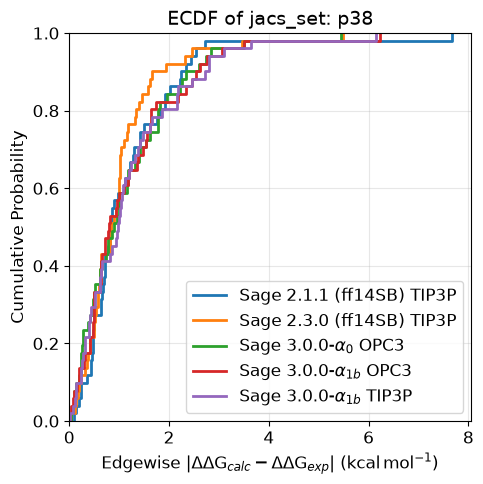

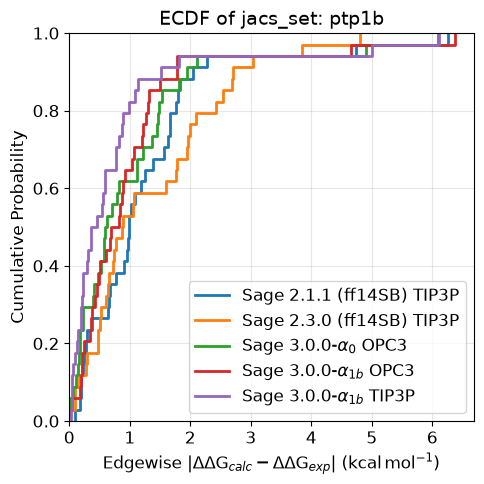

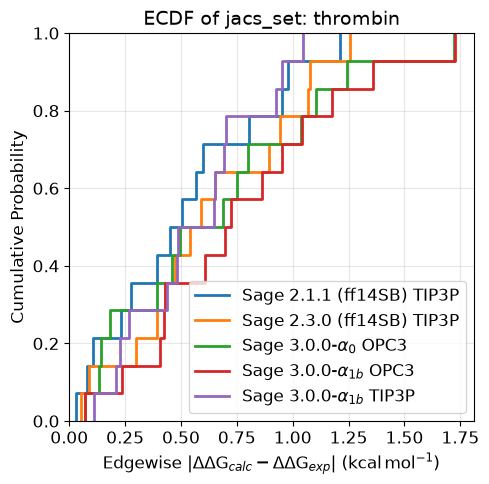

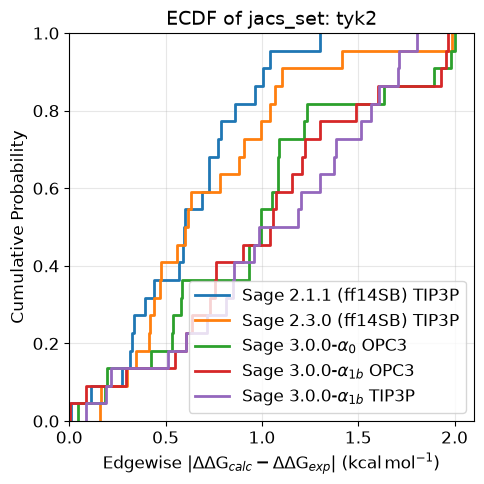

In [6]:
system_keys = next(iter(results.values())).ddg_femaps().keys()
for system_group_name in system_keys:
    femap_list = [result.ddg_femaps()[system_group_name] for result in results.values()]
    combined_femap = sum(femap_list[1:], femap_list[0])
    fig = plotting.ecdf_plot_DDGs(
        combined_femap,
        title=f"ECDF of {system_group_name[0]}: {system_group_name[1]}",
        #    sources=["Method A", "Method B"], # narrow down sources
        #    labels=["Pipeline A", "Pipeline B"], # set custom labels
        figsize=5,
        nbootstraps=0,  # optionally turn off uncertainty intervals
    )

## Compare and Rank Results

See [cinnebar documentation](https://cinnabar.openfree.energy/en/latest/tutorials/results_comparison.html) for more details.

In [29]:
# Combining FEMaps
system_group_name = ("jacs_set", "bace")

femap_list = [result.ddg_femaps()[system_group_name] for result in results.values()]
combined_femap = sum(femap_list[1:], femap_list[0])

In [30]:
summary_df, comparison_df = compare_and_rank_results(
    femap=combined_femap,
    prediction_type="edgewise",
    rank_metric="MUE",  # the metric used for ranking the results
    metrics_to_compute=["MUE", "RMSE"],  # metrics to report in the summary table
    num_bootstraps=5_000,
    confidence_level=0.95,  # report 95 % confidence intervals
    alpha=0.05,  # for statistical significance testing (e.g. p-value threshold)
)

In [31]:
summary_df

,Model,MUE,MUE_CI_Lower,MUE_CI_Upper,RMSE,RMSE_CI_Lower,RMSE_CI_Upper,CLD
0,Sage 2.1.1 (ff14SB) TIP3P,0.963724,0.765604,1.172668,1.201406,0.963218,1.426554,a
1,Sage 2.3.0 (ff14SB) TIP3P,0.853040,0.678852,1.046308,1.071311,0.841590,1.300246,a
2,Sage 3.0.0-$\alpha_0$ OPC3,0.783468,0.627688,0.949790,0.971617,0.783019,1.155954,a
3,Sage 3.0.0-$\alpha_{1b}$ OPC3,0.799819,0.640845,0.969634,0.989507,0.805883,1.170706,a
4,Sage 3.0.0-$\alpha_{1b}$ TIP3P,0.787752,0.611439,0.974946,1.013828,0.772236,1.251079,a


In [32]:
comparison_df

,Model 1,Model 2,Diff in MUE,CI Lower,CI Upper,p-value,significant,p-value corrected
0,Sage 2.1.1 (ff14SB) TIP3P,Sage 2.3.0 (ff14SB) TIP3P,0.110684,-0.001598,0.230933,0.0560,False,0.3920
1,Sage 2.1.1 (ff14SB) TIP3P,Sage 3.0.0-$\alpha_0$ OPC3,0.180256,0.042887,0.323360,0.0092,False,0.0880
2,Sage 2.1.1 (ff14SB) TIP3P,Sage 3.0.0-$\alpha_{1b}$ OPC3,0.163905,0.025936,0.313891,0.0176,False,0.1408
3,Sage 2.1.1 (ff14SB) TIP3P,Sage 3.0.0-$\alpha_{1b}$ TIP3P,0.175972,0.036527,0.316717,0.0088,False,0.0880
4,Sage 2.3.0 (ff14SB) TIP3P,Sage 3.0.0-$\alpha_0$ OPC3,0.069572,-0.039699,0.180607,0.2276,False,1.0000
5,Sage 2.3.0 (ff14SB) TIP3P,Sage 3.0.0-$\alpha_{1b}$ OPC3,0.053221,-0.049512,0.160709,0.3200,False,1.0000
6,Sage 2.3.0 (ff14SB) TIP3P,Sage 3.0.0-$\alpha_{1b}$ TIP3P,0.065288,-0.044625,0.182758,0.2508,False,1.0000
7,Sage 3.0.0-$\alpha_0$ OPC3,Sage 3.0.0-$\alpha_{1b}$ OPC3,-0.016351,-0.096087,0.072500,0.7072,False,1.0000
8,Sage 3.0.0-$\alpha_0$ OPC3,Sage 3.0.0-$\alpha_{1b}$ TIP3P,-0.004284,-0.103212,0.101296,0.9380,False,1.0000
9,Sage 3.0.0-$\alpha_{1b}$ OPC3,Sage 3.0.0-$\alpha_{1b}$ TIP3P,0.012068,-0.104943,0.136909,0.8620,False,1.0000


In [33]:
def plot_comparison(summary_df, title):
    cinnabar_colors = sns.color_palette(None, n_colors=len(summary_df))

    # Dynamically find all metrics with CI_Lower and CI_Upper
    metrics, seen = [], set()
    for col in summary_df.columns:
        if "_CI_" in col:
            metric_name = col.split("_CI_")[0]
            if metric_name not in seen:
                if (
                    f"{metric_name}_CI_Lower" in summary_df.columns
                    and f"{metric_name}_CI_Upper" in summary_df.columns
                ):
                    metrics.append(
                        (
                            metric_name,
                            [
                                metric_name,
                                f"{metric_name}_CI_Lower",
                                f"{metric_name}_CI_Upper",
                            ],
                        )
                    )
                    seen.add(metric_name)

    fig, axes = plt.subplots(1, len(metrics), figsize=(7 * len(metrics), 5))

    # Handle single metric case (axes won't be an array)
    if len(metrics) == 1:
        axes = [axes]

    # Define hatch patterns for unique CLD values
    hatches = ["", "///", "\\\\\\", "xxx", "|||", "---", "+++", "***"]
    unique_clds = summary_df["CLD"].unique()
    cld_hatch_map = {
        cld: hatches[i % len(hatches)] for i, cld in enumerate(unique_clds)
    }

    x = np.arange(len(summary_df))
    width = 0.6

    for ax, (metric_name, columns) in zip(axes, metrics):
        value_col, lower_col, upper_col = columns

        # Draw one bar per row
        for i, (idx, row) in enumerate(summary_df.iterrows()):
            ax.bar(
                i,
                row[value_col],
                width,
                yerr=[
                    [row[value_col] - row[lower_col]],
                    [row[upper_col] - row[value_col]],
                ],
                color=cinnabar_colors[i % len(cinnabar_colors)],
                hatch=cld_hatch_map[row["CLD"]],
                capsize=5,
                error_kw={"elinewidth": 2},
            )

        ax.set_ylabel(metric_name)
        ax.set_xticks(x)
        ax.set_ylim(bottom=0)
        ax.set_xticklabels(summary_df.Model, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

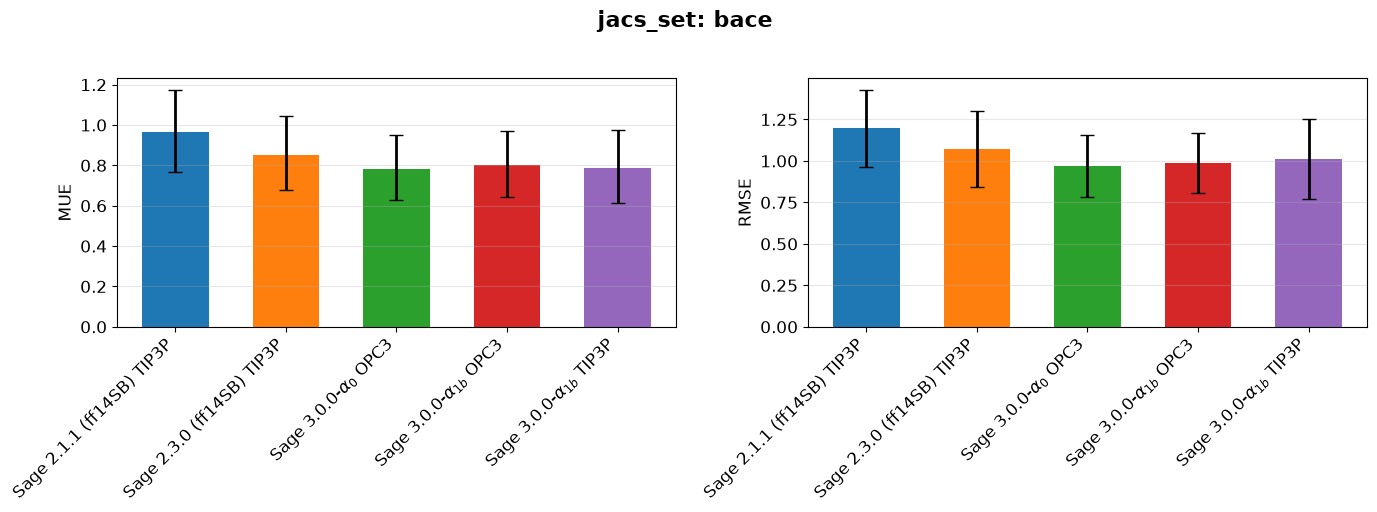

In [34]:
plot_comparison(summary_df, f"{system_group_name[0]}: {system_group_name[1]}")

### Plot Comparisons of All Systems

Statistically similar groupings of force fields have the same hatching in their bars

In [35]:
def plot_all_comparisons(summary_dict, title):
    # Combine all DataFrames with key labels
    dfs_with_keys = []
    for key, df in summary_dict.items():
        df_copy = df.copy()
        df_copy["key"] = key
        dfs_with_keys.append(df_copy)

    combined_df = pd.concat(dfs_with_keys, ignore_index=True)

    # Get unique models and assign consistent colors
    unique_models = sorted(combined_df["Model"].unique())
    cinnabar_colors = sns.color_palette(None, n_colors=len(unique_models))
    model_colors = {
        model: color for model, color in zip(unique_models, cinnabar_colors)
    }

    # Dynamically find all metrics with CI_Lower and CI_Upper
    metrics, seen = [], set()
    for col in combined_df.columns:
        if "_CI_" in col:
            metric_name = col.split("_CI_")[0]
            if metric_name not in seen:
                if (
                    f"{metric_name}_CI_Lower" in combined_df.columns
                    and f"{metric_name}_CI_Upper" in combined_df.columns
                ):
                    metrics.append(
                        (
                            metric_name,
                            [
                                metric_name,
                                f"{metric_name}_CI_Lower",
                                f"{metric_name}_CI_Upper",
                            ],
                        )
                    )
                    seen.add(metric_name)

    fig, axes = plt.subplots(1, len(metrics), figsize=(7 * len(metrics), 5))

    if len(metrics) == 1:
        axes = [axes]

    # Define hatch patterns for unique CLD values
    hatches = ["", "///", "\\\\\\", "xxx", "|||", "---", "+++", "***"]
    unique_clds = sorted(combined_df["CLD"].unique())
    cld_hatch_map = {
        cld: hatches[i % len(hatches)] for i, cld in enumerate(unique_clds)
    }

    # Get unique keys
    unique_keys = list(summary_dict.keys())
    n_keys = len(unique_keys)
    n_models = len(unique_models)

    # Calculate positions for grouped bars
    width = 0.12
    x_positions = np.arange(n_keys)

    for ax, (metric_name, columns) in zip(axes, metrics):
        value_col, lower_col, upper_col = columns

        # Draw bars for each model within each key group
        for model_idx, model in enumerate(unique_models):
            model_data = combined_df[combined_df["Model"] == model]

            for idx, row in model_data.iterrows():
                key = row["key"]
                key_pos = unique_keys.index(key)

                # Calculate x position: center group, then offset by model
                x_pos = key_pos + (model_idx - n_models / 2 + 0.5) * width

                ax.bar(
                    x_pos,
                    row[value_col],
                    width,
                    yerr=[
                        [row[value_col] - row[lower_col]],
                        [row[upper_col] - row[value_col]],
                    ],
                    color=model_colors[model],
                    hatch=cld_hatch_map[row["CLD"]],
                    capsize=3,
                    error_kw={"elinewidth": 1.5},
                )

        ax.set_ylabel(metric_name)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(unique_keys, rotation=45, ha="right")
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=0.3)

    # Single legend for models
    model_patches = [
        Patch(facecolor=model_colors[model], label=model) for model in unique_models
    ]
    fig.legend(
        handles=model_patches,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=n_models,
    )

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

In [36]:
system_keys = next(iter(results.values())).ddg_femaps().keys()
comparison_results = {}
for system_group_name in system_keys:
    femap_list = [result.ddg_femaps()[system_group_name] for result in results.values()]
    combined_femap = sum(femap_list[1:], femap_list[0])

    summary_df, comparison_df = compare_and_rank_results(
        femap=combined_femap,
        prediction_type="edgewise",
        rank_metric="MUE",  # the metric used for ranking the results
        metrics_to_compute=["MUE", "RMSE"],  # metrics to report in the summary table
        num_bootstraps=10_000,
        confidence_level=0.95,  # report 95 % confidence intervals
        alpha=0.05,  # for statistical significance testing (e.g. p-value threshold)
    )
    comparison_results[system_group_name[1]] = summary_df
    print(system_group_name)
    print(summary_df)

('jacs_set', 'bace')
                            Model       MUE  MUE_CI_Lower  MUE_CI_Upper  \
0       Sage 2.1.1 (ff14SB) TIP3P  0.963724      0.769530      1.175633   
1       Sage 2.3.0 (ff14SB) TIP3P  0.853040      0.682010      1.046940   
2      Sage 3.0.0-$\alpha_0$ OPC3  0.783468      0.629431      0.951045   
3   Sage 3.0.0-$\alpha_{1b}$ OPC3  0.799819      0.645539      0.968720   
4  Sage 3.0.0-$\alpha_{1b}$ TIP3P  0.787752      0.619981      0.978233   

       RMSE  RMSE_CI_Lower  RMSE_CI_Upper CLD  
0  1.201406       0.967563       1.429915   a  
1  1.071311       0.845773       1.302325   a  
2  0.971617       0.785138       1.157214   a  
3  0.989507       0.808656       1.172244   a  
4  1.013828       0.783117       1.247433   a  
('jacs_set', 'cdk2')
                            Model       MUE  MUE_CI_Lower  MUE_CI_Upper  \
0       Sage 2.1.1 (ff14SB) TIP3P  0.731745      0.500625      0.990163   
1       Sage 2.3.0 (ff14SB) TIP3P  0.618675      0.427279      0.8312

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dr/9nnhm1493kv7_s9r_wj_l_jm0000gn/T/ipykernel_27834/2518052084.py:1: SyntaxWarning: invalid escape sequence '\D'
  plot_all_comparisons(comparison_results, "JACS Set: $\Delta\Delta G$")


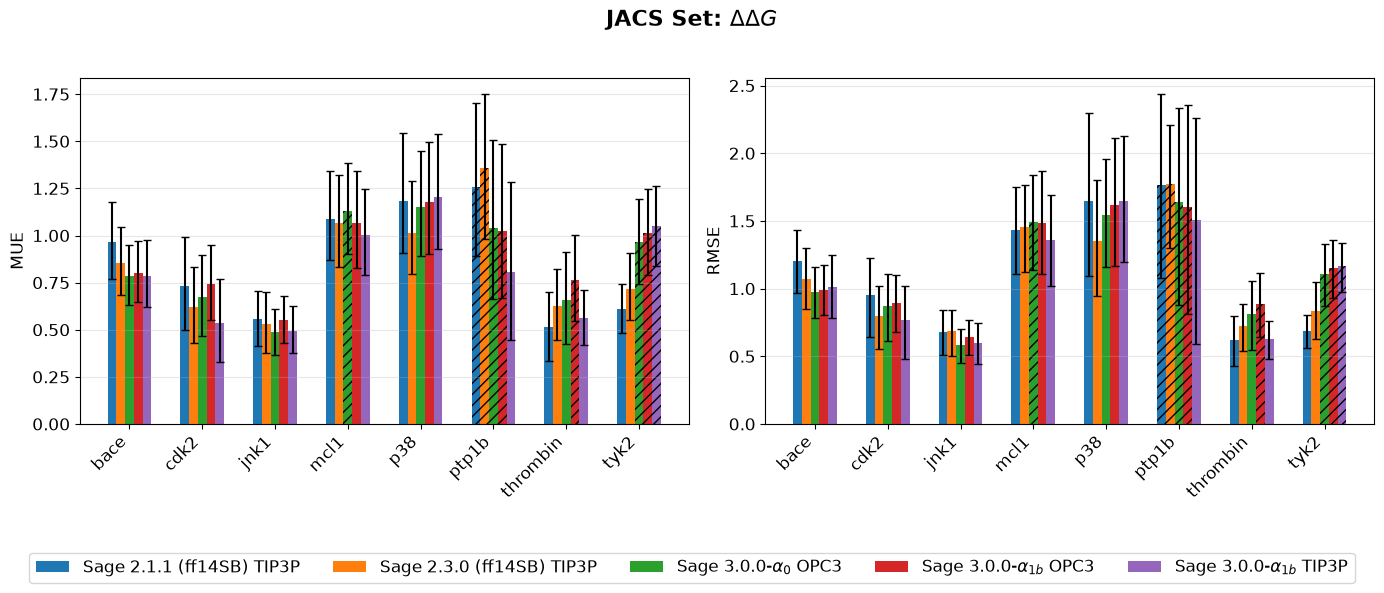

In [37]:
plot_all_comparisons(comparison_results, "JACS Set: $\Delta\Delta G$")

## Compare Ligand-Only Safe 3.0.0-alpha1b Subset

In [38]:
results_subset = get_benchmark_results(
    "2026-08-05_ff14sb_openff-3.0.0-alpha1b_tip3p_jacs_tyk2_thrombin"
)
results_subset.ddg_femaps(source=r"Sage 3.0.0-$\alpha_{1b}$ (ff14SB) TIP3P")

2026-08-31 12:56:13 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for ddg results - first access may be slow
2026-08-31 12:56:13 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'thrombin' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-31 12:56:13 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'tyk2' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network


{('jacs_set', 'thrombin'): <cinnabar.femap.FEMap at 0x177f0de80>,
 ('jacs_set', 'tyk2'): <cinnabar.femap.FEMap at 0x17769b590>}

In [39]:
system_keys = results_subset.ddg_femaps().keys()
comparison_results = {}
for system_group_name in system_keys:
    femap_list = [result.ddg_femaps()[system_group_name] for result in results.values()]
    combined_femap = sum(femap_list, results_subset.ddg_femaps()[system_group_name])

    summary_df, comparison_df = compare_and_rank_results(
        femap=combined_femap,
        prediction_type="edgewise",
        rank_metric="MUE",  # the metric used for ranking the results
        metrics_to_compute=["MUE", "RMSE"],  # metrics to report in the summary table
        num_bootstraps=10_000,
        confidence_level=0.95,  # report 95 % confidence intervals
        alpha=0.05,  # for statistical significance testing (e.g. p-value threshold)
    )
    comparison_results[system_group_name[1]] = summary_df

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dr/9nnhm1493kv7_s9r_wj_l_jm0000gn/T/ipykernel_27834/2518052084.py:1: SyntaxWarning: invalid escape sequence '\D'
  plot_all_comparisons(comparison_results, "JACS Set: $\Delta\Delta G$")


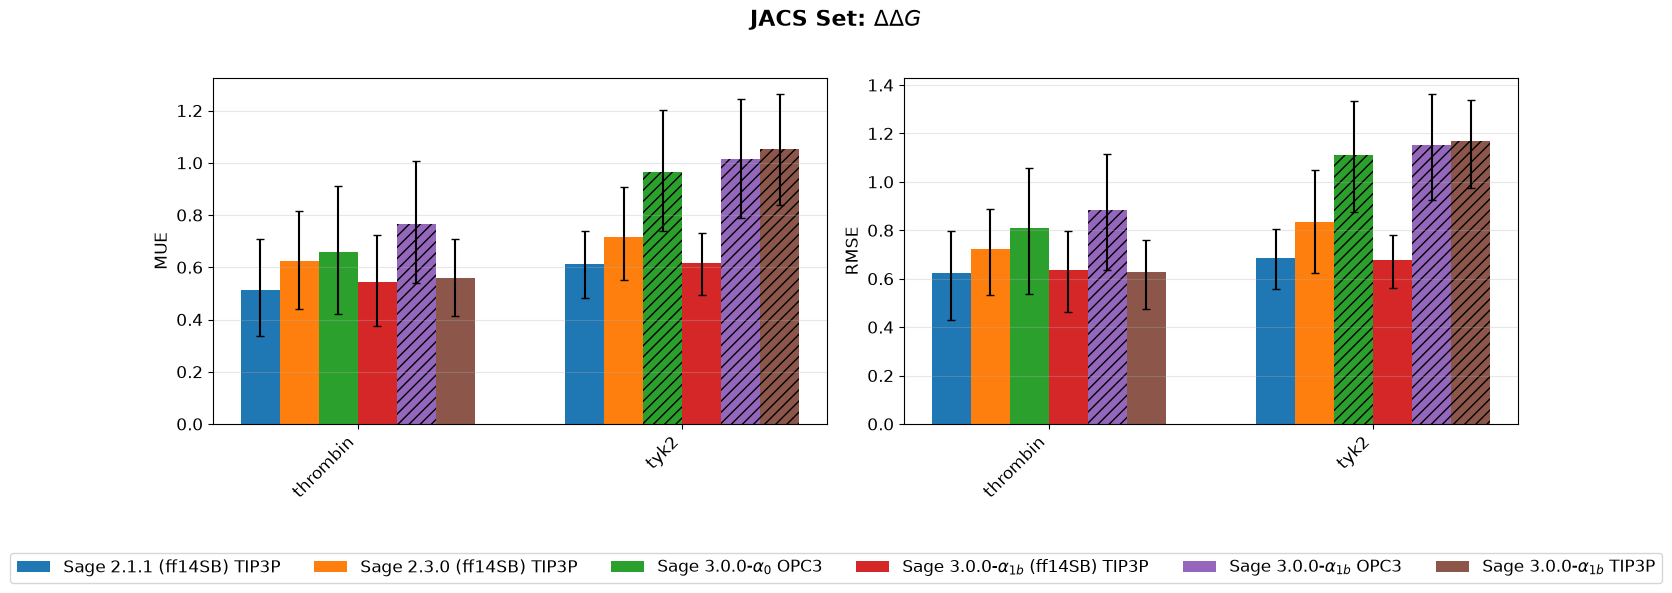

In [40]:
plot_all_comparisons(comparison_results, "JACS Set: $\Delta\Delta G$")

## Get dG Comparisons

In [41]:
for key, result in results.items():
    result.dg_femaps(source=key, force_source_update=True)

In [42]:
system_keys = next(iter(results.values())).ddg_femaps().keys()
comparison_results = {}
for system_group_name in system_keys:
    femap_list = [
        result.dg_femaps(source=key)[system_group_name]
        for key, result in results.items()
    ]
    combined_femap = sum(femap_list[1:], femap_list[0])

    summary_df, comparison_df = compare_and_rank_results(
        femap=combined_femap,
        prediction_type="nodewise",
        rank_metric="KTAU",  # the metric used for ranking the results
        metrics_to_compute=["KTAU", "RMSE"],  # metrics to report in the summary table
        num_bootstraps=10_000,
        confidence_level=0.95,  # report 95 % confidence intervals
        alpha=0.05,  # for statistical significance testing (e.g. p-value threshold)
    )
    comparison_results[system_group_name[1]] = summary_df

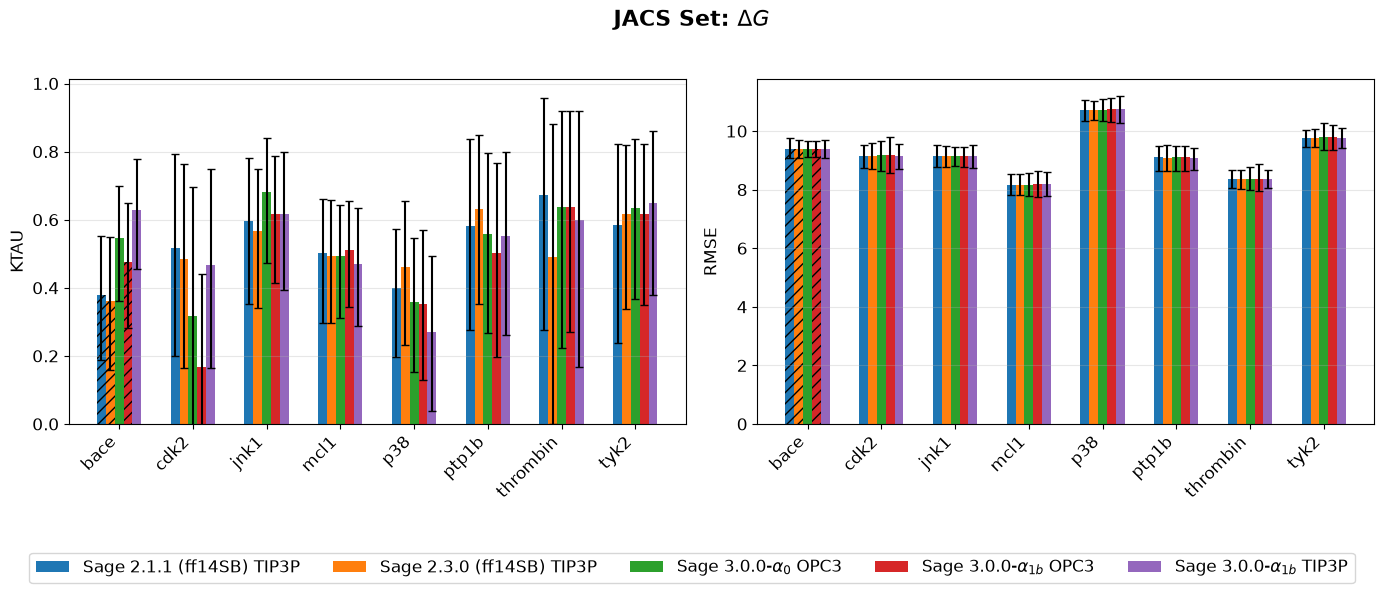

In [43]:
plot_all_comparisons(comparison_results, r"JACS Set: $\Delta G$")